In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from google.colab import files
uploaded = files.upload()

Saving Sample - Superstore.csv.zip to Sample - Superstore.csv (1).zip


In [5]:
import zipfile
import io

# Get the name of the uploaded zip file
zip_filename = list(uploaded.keys())[0]

# Get the content of the uploaded zip file
zip_file_content = uploaded[zip_filename]

# Use BytesIO to treat the byte content as a file
zip_file_object = io.BytesIO(zip_file_content)

# Open the zip file
with zipfile.ZipFile(zip_file_object, 'r') as z:
    # Find the first .csv file in the zip archive
    csv_filename_in_zip = None
    for name in z.namelist():
        if name.endswith('.csv'):
            csv_filename_in_zip = name
            break

    if csv_filename_in_zip:
        # Open the CSV file from the zip archive and read it into a DataFrame
        with z.open(csv_filename_in_zip) as csv_file:
            df = pd.read_csv(csv_file, encoding='latin1')
    else:
        # If no CSV is found, raise an error
        raise ValueError("No CSV file found in the uploaded zip archive.")

In [7]:
import zipfile
import io

# Get the name of the uploaded zip file (e.g., 'Sample - Superstore.csv (1).zip')
zip_filename = list(uploaded.keys())[0]

# Get the content of the uploaded zip file as bytes
zip_file_content = uploaded[zip_filename]

# Use BytesIO to treat the byte content as a file
zip_file_object = io.BytesIO(zip_file_content)

# Open the zip file
with zipfile.ZipFile(zip_file_object, 'r') as z:
    # Find the first .csv file in the zip archive
    csv_filename_in_zip = None
    for name in z.namelist():
        if name.endswith('.csv'):
            csv_filename_in_zip = name
            break

    if csv_filename_in_zip:
        # Open the CSV file from the zip archive and read it into a DataFrame
        with z.open(csv_filename_in_zip) as csv_file:
            df = pd.read_csv(csv_file, encoding='latin1')
    else:
        # If no CSV is found, raise an error
        raise ValueError("No CSV file found in the uploaded zip archive.")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


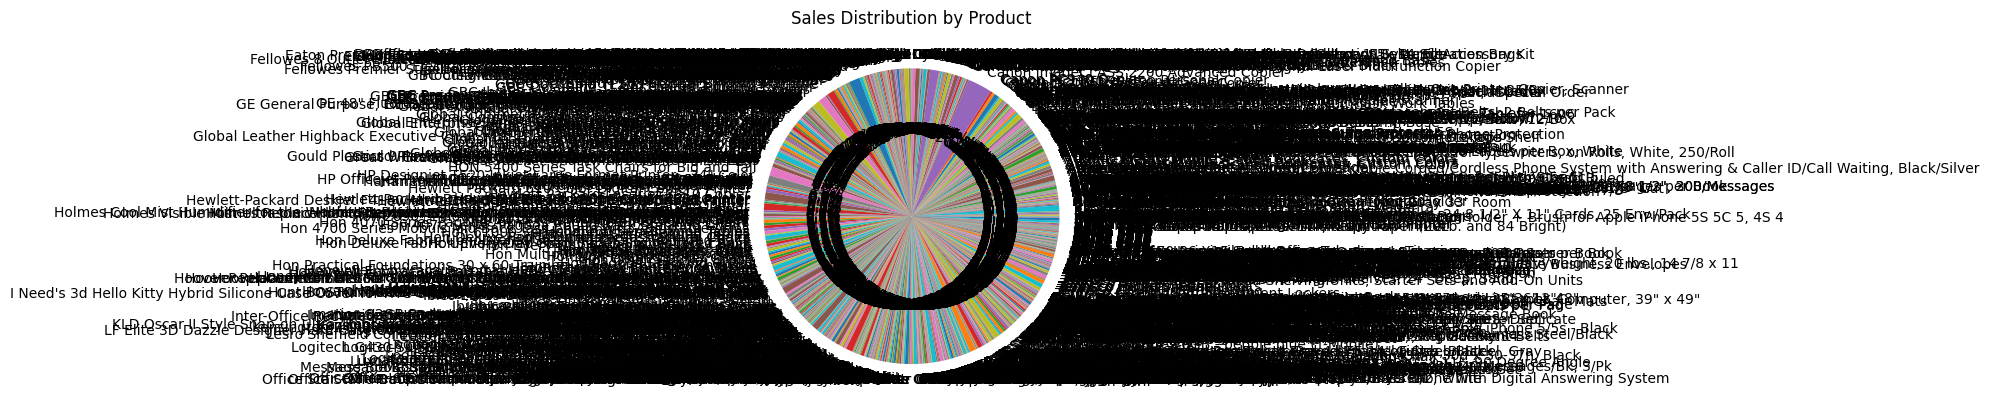

In [11]:
product_sales = df.groupby("Product Name")["Sales"].sum()

plt.figure()
product_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Product")
plt.ylabel("")
plt.show()

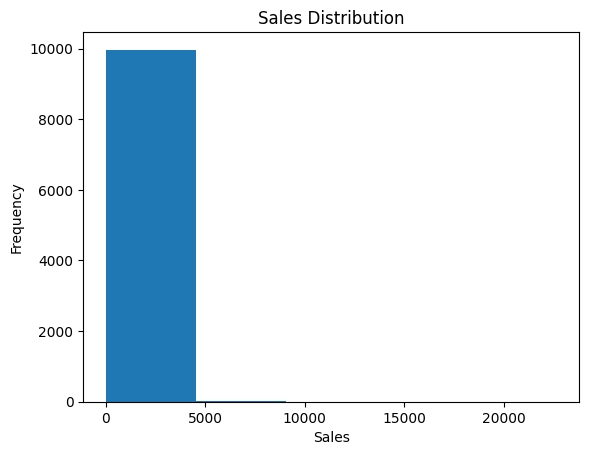

In [12]:
plt.figure()
df["Sales"].plot(kind='hist', bins=5)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

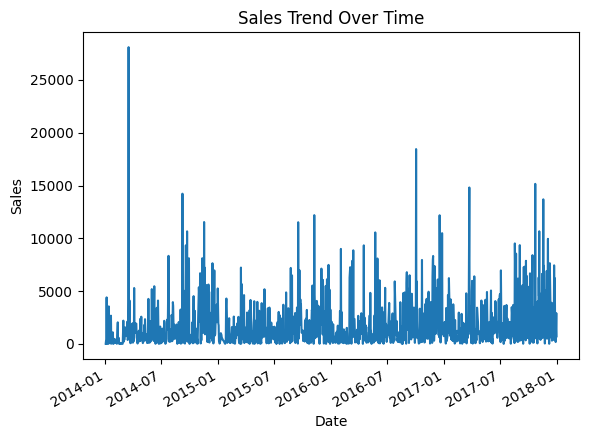

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure()
sales_trend.plot(kind='line')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

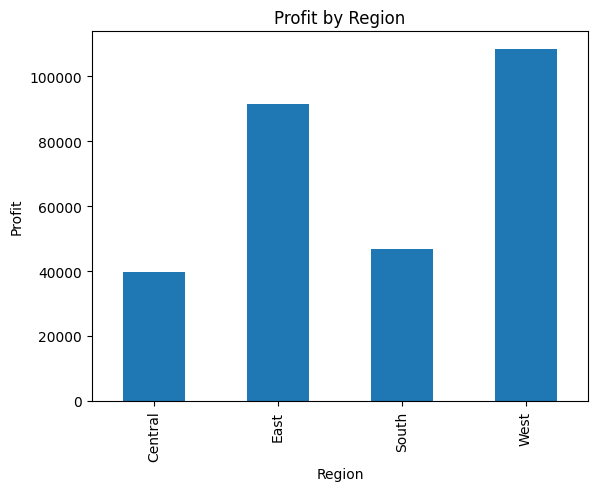

In [15]:
region_profit = df.groupby("Region")["Profit"].sum()

plt.figure()
region_profit.plot(kind='bar')
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()